## About the Project

This project uses the k-means clustering algorithm to segment credit card users into different clusters based on their use behavior. The customer behavioral variables are as follows:

- BALANCE: Balance amount left in their account to make purchases.
- BALANCE_FREQUENCY: How frequently the Balance is updated, score between 0 and 1 (1 = frequently updated, 0 = not frequently updated).
- PURCHASES: Amount of purchases made from account.
- ONEOFF_PURCHASES: Maximum purchase amount done in one-go (i.e., one-time payment for a purchase).
- INSTALLMENTS_PURCHASES: Amount of purchase done in installment (i.e., multiple payments for a purchase). Observation: PURCHASES = ONEOFF_PURCHASE + INSTALLMENT_PURCHASES).
- CASH_ADVANCE: Cash in advance given by the user (a cash advance is when taking money out of the ATM using credit card instead of debit card or ATM card).
- PURCHASES_FREQUENCY: How frequently the Purchases are being made, score between 0 and 1 (1 = frequently purchased, 0 = not frequently purchased).
- ONEOFF_PURCHASES_FREQUENCY: How frequently Purchases are happening in one-go (1 = frequently purchased, 0 = not frequently purchased).
- PURCHASES_INSTALLMENTS_FREQUENCY: How frequently purchases in installments are being done (1 = frequently done, 0 = not frequently done).
- CASH_ADVANCE_FREQUENCY: How frequently the cash in advance being paid.
- CASH_ADVANCE_TRX: Number of Transactions made with "Cash in Advanced".
- PURCHASES_TRX: Number of purchase transactions made.
- CREDIT_LIMIT: Limit of Credit Card for user.
- PAYMENTS: Amount of payment done by user (i.e., payment for the use of credit card)
- MINIMUM_PAYMENTS: Minimum amount of payments made by user.
- PRC_FULL_PAYMENT: Percent of full payment paid by user.
- TENURE: Tenure of credit card service for user (i.e., how long (in months) you should have held the credit card before they will grant you credit).

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Load dataset in pandas dataframe
df = pd.read_csv("credit-card-holder-data.csv")

In [56]:
# Show several 
df.head(n=20)

,Unnamed: 0,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,3,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12
4,4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
5,5,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12
6,6,627.260806,1.000000,7091.01,6402.63,688.38,0.000000,1.000000,1.000000,1.000000,0.000000,0,64,13500.0,6354.314328,198.065894,1.000000,12
7,7,1823.652743,1.000000,436.20,0.00,436.20,0.000000,1.000000,0.000000,1.000000,0.000000,0,12,2300.0,679.065082,532.033990,0.000000,12
8,8,1014.926473,1.000000,861.49,661.49,200.00,0.000000,0.333333,0.083333,0.250000,0.000000,0,5,7000.0,688.278568,311.963409,0.000000,12
9,9,152.225975,0.545455,1281.60,1281.60,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,3,11000.0,1164.770591,100.302262,0.000000,12


In [ ]:
df.drop(columns = ["Unnamed: 0"], inplace=True)
df.info()
df.describe()
#No NaN/Null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   BALANCE                           8950 non-null   float64
 1   BALANCE_FREQUENCY                 8950 non-null   float64
 2   PURCHASES                         8950 non-null   float64
 3   ONEOFF_PURCHASES                  8950 non-null   float64
 4   INSTALLMENTS_PURCHASES            8950 non-null   float64
 5   CASH_ADVANCE                      8950 non-null   float64
 6   PURCHASES_FREQUENCY               8950 non-null   float64
 7   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 8   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 9   CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 10  CASH_ADVANCE_TRX                  8950 non-null   int64  
 11  PURCHASES_TRX                     8950 non-null   int64  
 12  CREDIT

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.612411,2895.063757,2330.588021,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,170.857654,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,335.628312,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,864.206542,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


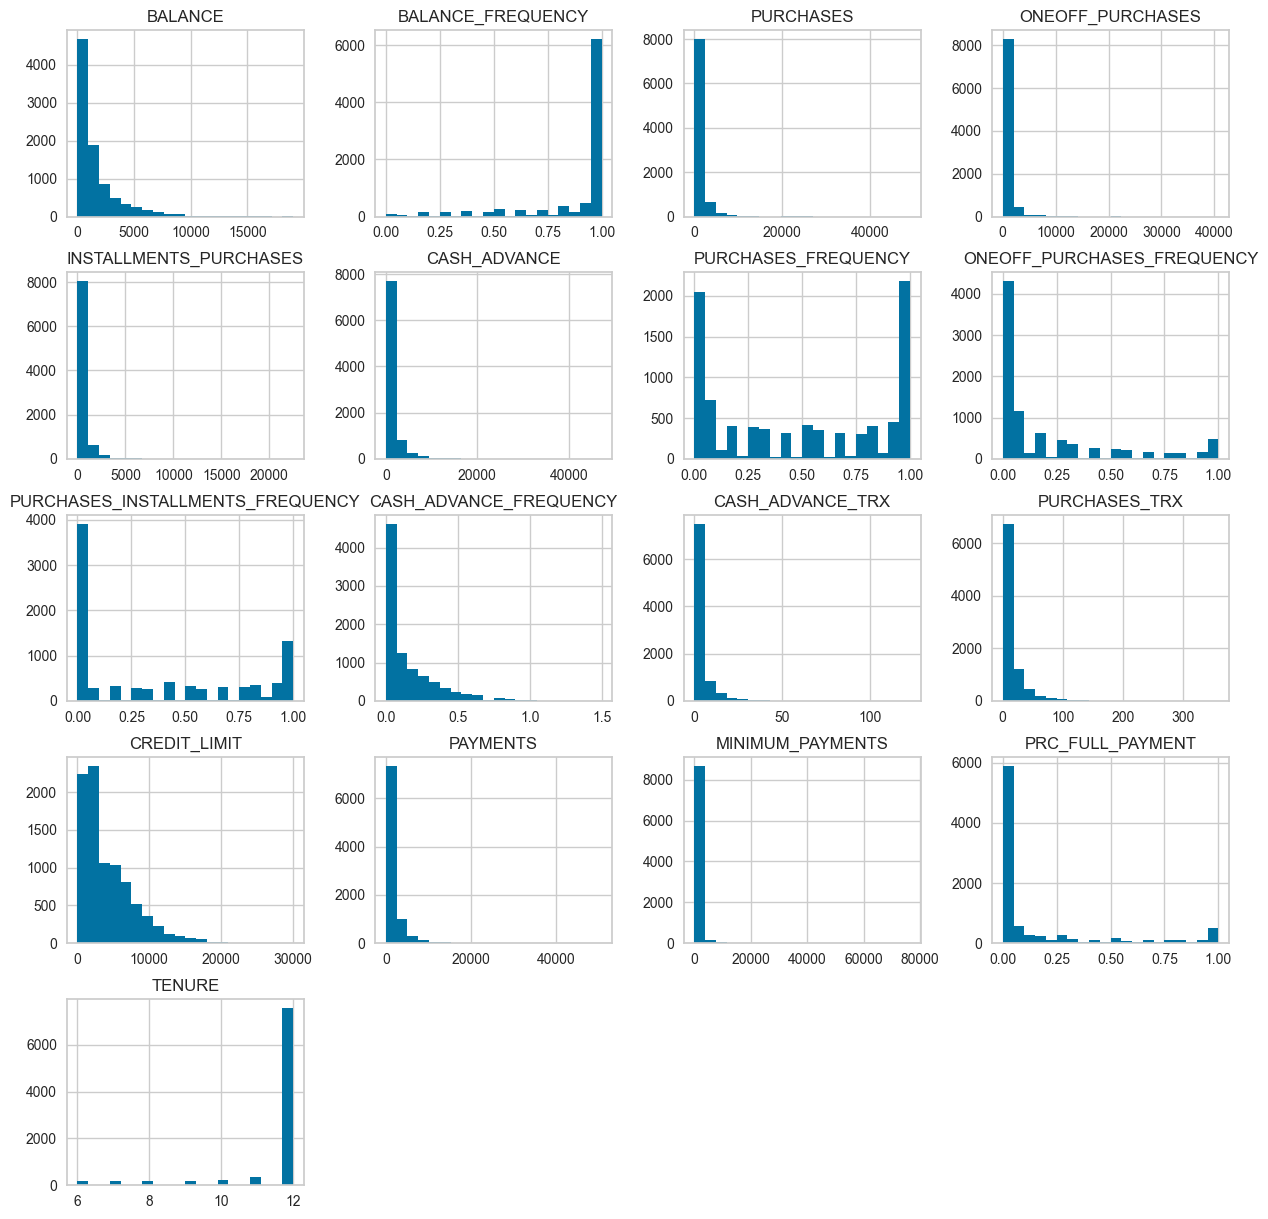

In [ ]:
df.hist(bins=20, figsize=(15, 15))
plt.show()
#want to see distribution shape of each feature (all are continuous/discrete numerical)

<Axes: >

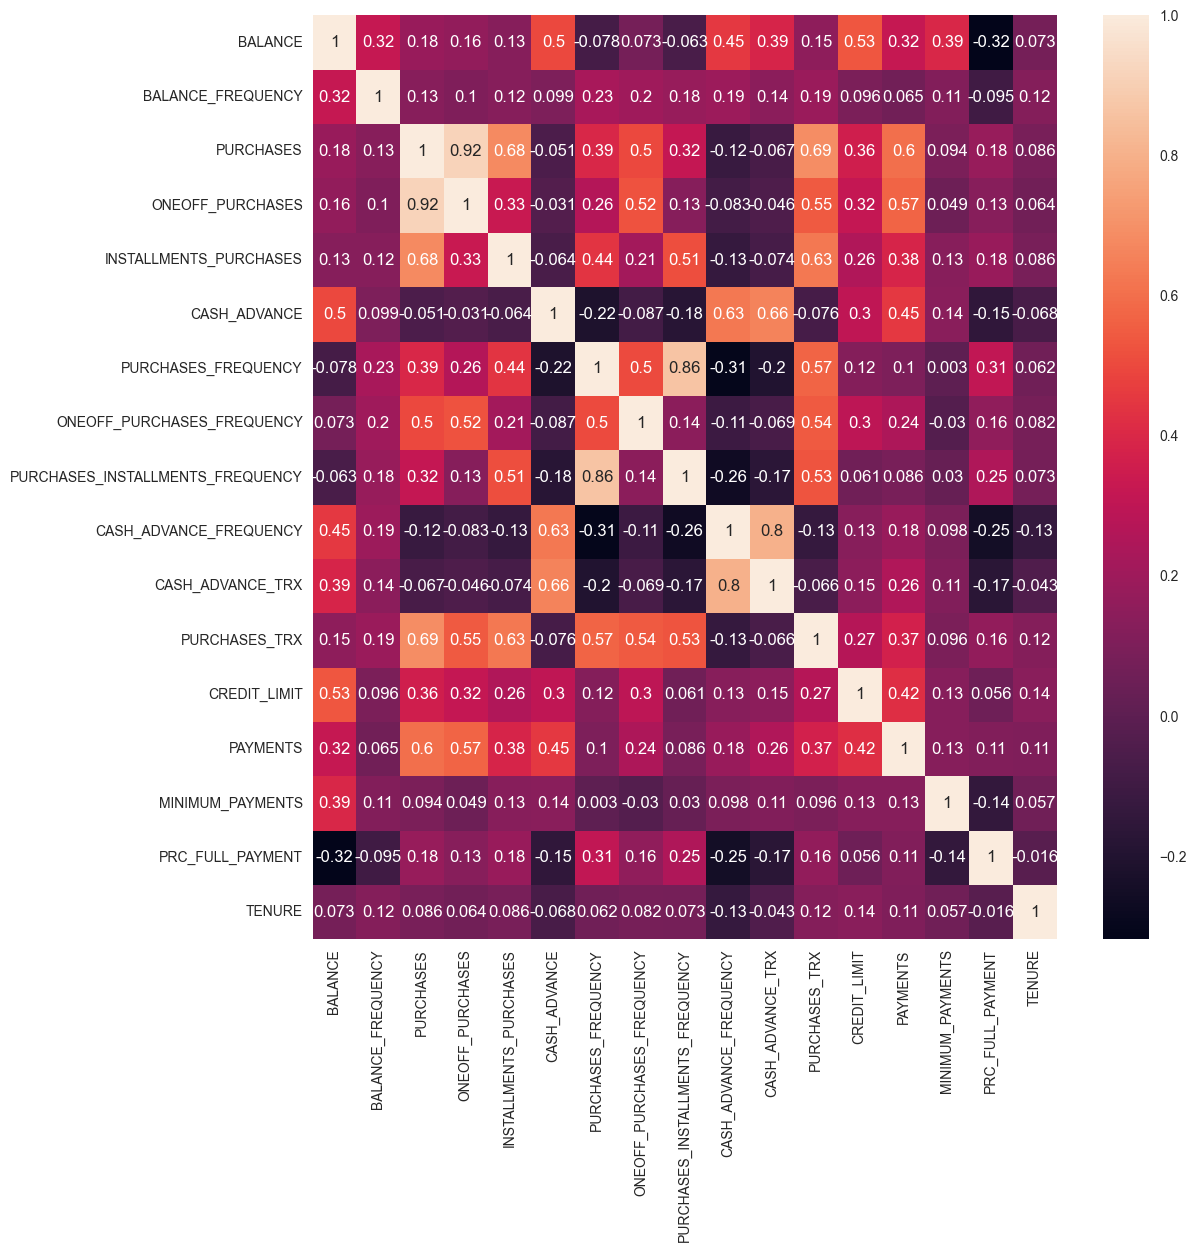

In [ ]:
plt.figure(figsize=(12, 12))
sns.heatmap(df.corr(), annot=True)
#want to see feature relationships

In [60]:
data = df.copy()

In [61]:
from sklearn.preprocessing import StandardScaler
normalizer = StandardScaler()

scaled_data = normalizer.fit_transform(data.values)

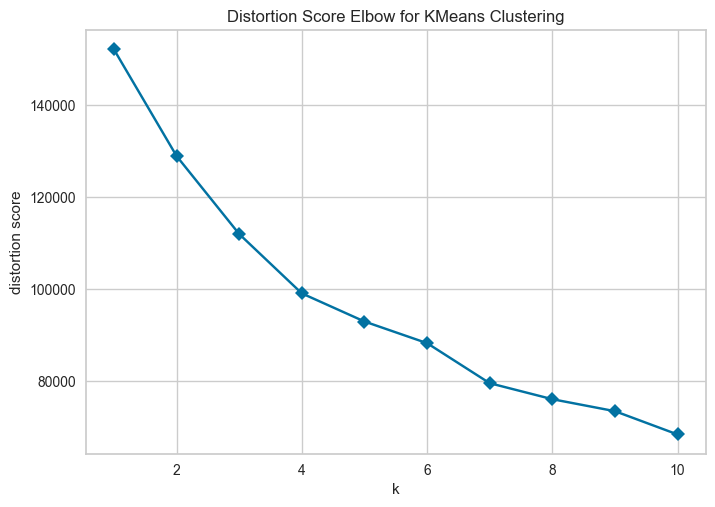

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans

elbow_method = KElbowVisualizer(KMeans(), k=(1,11), timings=False, locate_elbow=False)
elbow_method.fit(scaled_data)
elbow_method.show()

In [ ]:
# The elbow method did not give a clear choice for k as the loss function kept decreasing without 
# plateauing --> there is no apparent elbow. I think, without using any method, domain knowledge would
# be important in determining the number of clusters. For example, businesses may want to segments their 
# customers into few categories for easy strategizing while you may need way higher k number in 
# clustering gene expression data which could correspond to thousands of different biological pathways. 
# That said, according to my reading, two alternative methods is the silhouette method, which 
# measures similarity of each point to its own cluster compared to another cluster, and gap statistic, 
# which compares the clustering result with randomly distributed data to see how well the resulting 
# structure fits the data.

#Choose k=4 based on elbow method, there's actually no clear elbow, but 4 seems like a good estimation
KMeansModel = KMeans(n_clusters=4)
KMeansModel.fit(scaled_data)

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [ ]:
# KMeansModel.labels_
import numpy as np
unique_val, counts = np.unique(KMeansModel.labels_, return_counts=True)
counts

array([3349, 3966, 1225,  410])

In [65]:
KMeansModel.predict(scaled_data)

array([1, 2, 0, ..., 0, 1, 1], shape=(8950,), dtype=int32)

In [ ]:
KMeansModel.cluster_centers_

array([[-3.20466534e-01,  2.50746647e-01,  1.10982785e-01,
         2.33155937e-03,  2.57907008e-01, -3.66202781e-01,
         9.86723247e-01,  3.19633386e-01,  8.77327386e-01,
        -4.62013317e-01, -3.60040332e-01,  2.99854038e-01,
        -7.58900438e-02, -1.37173350e-01, -9.11170303e-02,
         3.97116752e-01,  5.95958050e-02],
       [-2.74931476e-01, -3.79607809e-01, -3.42262623e-01,
        -2.30201384e-01, -3.86154183e-01, -1.90123799e-01,
        -7.90605403e-01, -3.87575291e-01, -7.08602224e-01,
        -1.12768807e-01, -1.72198264e-01, -4.73498350e-01,
        -3.37948910e-01, -2.64580369e-01, -1.25395081e-01,
        -2.56649536e-01, -5.48106959e-02],
       [ 1.43892521e+00,  3.85972836e-01, -2.41377376e-01,
        -1.70028108e-01, -2.58448944e-01,  1.65564584e+00,
        -5.18051014e-01, -2.21855284e-01, -4.61276139e-01,
         1.72409083e+00,  1.58734651e+00, -2.91402070e-01,
         8.17225239e-01,  5.84470359e-01,  4.92756572e-01,
        -4.05231092e-01, -9.3

In [ ]:
#Performs principle component analysis to reduce dimensionality for visualization
from sklearn.decomposition import PCA
pca = PCA(n_components=len(data.columns))
pca.fit(scaled_data)

print(pca.explained_variance_)
print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.cumsum())


[4.63982474e+00 3.45172419e+00 1.49480352e+00 1.27173785e+00
 1.06479362e+00 9.77645154e-01 8.30922729e-01 7.23853420e-01
 6.50969490e-01 5.23659568e-01 4.03267614e-01 3.01551195e-01
 2.42530713e-01 2.06975882e-01 1.72227523e-01 4.54007901e-02
 1.16501010e-05]
[2.72900372e-01 2.03019913e-01 8.79197945e-02 7.47997502e-02
 6.26279204e-02 5.75021129e-02 4.88723464e-02 4.25748554e-02
 3.82880445e-02 3.08000623e-02 2.37189739e-02 1.77363237e-02
 1.42649185e-02 1.21736915e-02 1.01298988e-02 2.67033632e-03
 6.85223491e-07]
[0.27290037 0.47592029 0.56384008 0.63863983 0.70126775 0.75876986
 0.80764221 0.85021707 0.88850511 0.91930517 0.94302415 0.96076047
 0.97502539 0.98719908 0.99732898 0.99999931 1.        ]


3D PCA

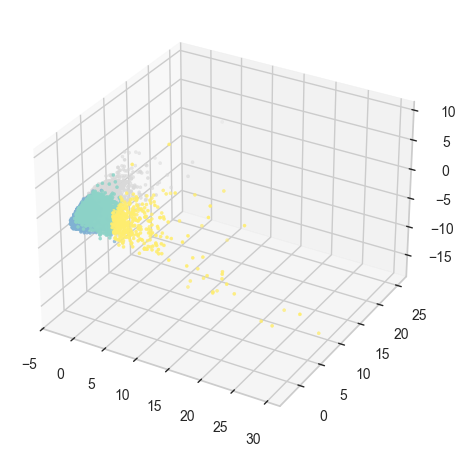

In [69]:
pca3d = PCA(n_components=3)
pca3d_data = pca3d.fit_transform(scaled_data)
pca3d_df = pd.DataFrame(pca3d_data, columns=["pca1", "pca2", "pca3"]) 

ax = plt.subplot(projection="3d")
ax.scatter(pca3d_df.pca1, pca3d_df.pca2, pca3d_df.pca3, c=KMeansModel.labels_, cmap="Set3", s=5)
plt.show()

2D PCA

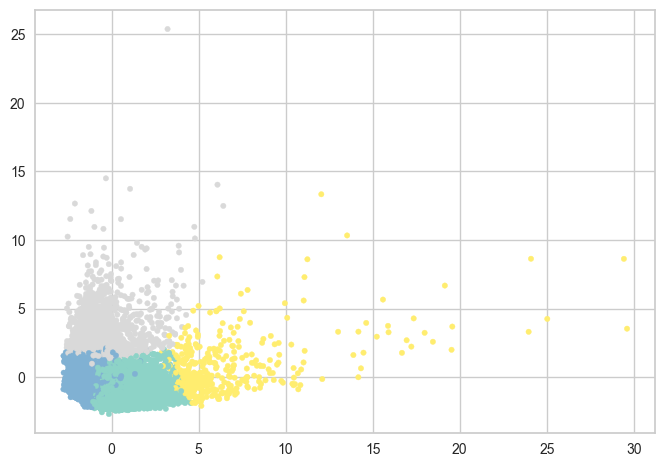

In [70]:
pca2d = PCA(n_components=2)
pca2d_data = pca2d.fit_transform(scaled_data)
pca2d_df = pd.DataFrame(pca2d_data, columns=["pca1", "pca2"]) 

ax = plt.subplot()
ax.scatter(pca2d_df.pca1, pca2d_df.pca2, c=KMeansModel.labels_, cmap="Set3", s=15)
plt.show()

In [ ]:
data1 = df.copy()
data1["Labels"] = KMeansModel.labels_
data1

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Labels
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,1
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,2
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,0
3,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12,1
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6,0
8946,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,864.206542,0.000000,6,0
8947,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6,0
8948,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6,1


In [ ]:

samples = data1.groupby("Labels").sample(n=5, random_state=10)
for label in samples["Labels"].unique():
    print()
    print(samples[samples["Labels"] == label])
    print("\n==================================================================\n")
#get some samples for inspection of the characteristics of each cluster


          BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
162    871.568977                1.0     648.22            115.00   
8824    88.633107                1.0     450.00              0.00   
4379   339.956112                1.0    2199.65            815.15   
1247  1121.833202                1.0    2940.00            750.00   
514   1191.584153                1.0    4238.79           2220.39   

      INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
162                   533.22           0.0             1.000000   
8824                  450.00           0.0             1.000000   
4379                 1384.50           0.0             0.916667   
1247                 2190.00           0.0             1.000000   
514                  2018.40           0.0             1.000000   

      ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
162                     0.083333                          1.000000   
8824                    0.000000         

' \nNotes:\n'

In [ ]:
for label in data1["Labels"].unique():
    description = data1[data1["Labels"] == label].describe()
    print(description)
#since this is too hard to read i will standardize the data then visualize the zscores onto heatmap for better visualization

           BALANCE  BALANCE_FREQUENCY    PURCHASES  ONEOFF_PURCHASES  \
count  3966.000000        3966.000000  3966.000000       3966.000000   
mean    996.276913           0.787651   271.777284        210.138069   
std    1083.779046           0.296141   467.082845        447.420388   
min       0.000000           0.000000     0.000000          0.000000   
25%      79.144735           0.545455     0.000000          0.000000   
50%     744.342979           1.000000    80.725000          0.000000   
75%    1478.077231           1.000000   343.070000        213.165000   
max    8115.039014           1.000000  4900.000000       4900.000000   

       INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
count             3966.000000   3966.000000          3966.000000   
mean                61.906911    581.892818             0.172910   
std                157.631137    903.545432             0.190848   
min                  0.000000      0.000000             0.000000   
25%        

<Axes: >

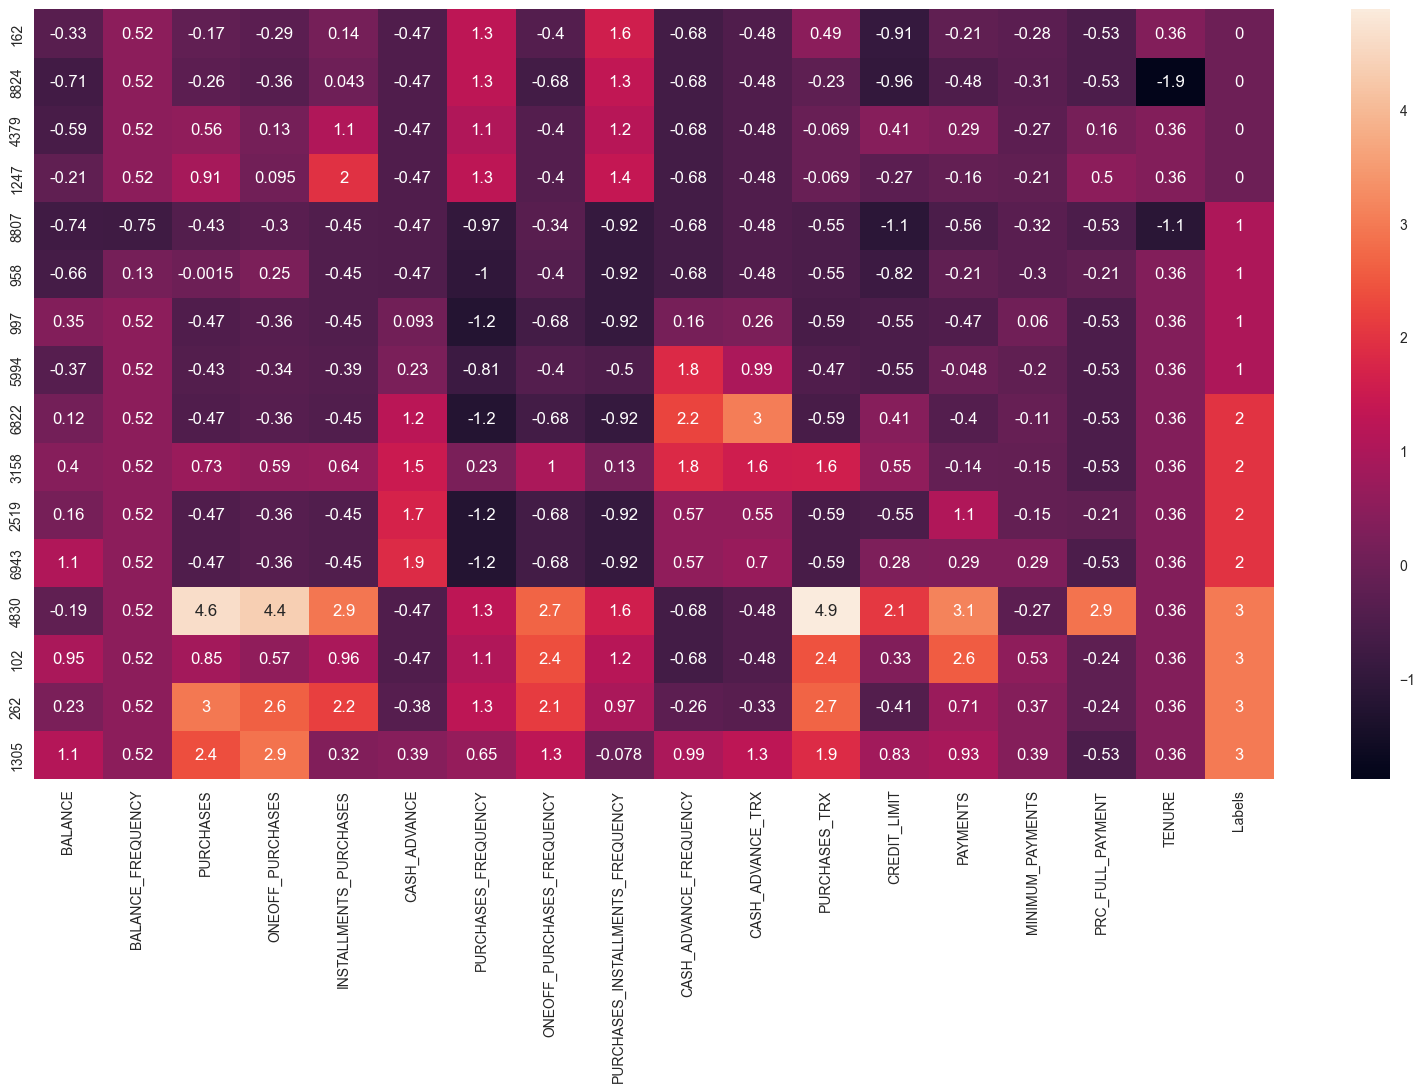

In [ ]:
norm_data1 = data1.copy()
scaled_cols = [col for col in data1.columns if col != "Labels"]
normalizer1 = StandardScaler()
norm_data1[scaled_cols] = normalizer1.fit_transform(data1[scaled_cols])
norm_data1 = pd.DataFrame(norm_data1, columns=data1.columns)
norm_data1


samples2 = norm_data1.groupby("Labels").sample(n=4, random_state=10)
plt.figure(figsize=(20, 10))
sns.heatmap(samples2, annot=True)
#heatmap of some sample data points with zscore of their feature data for better observation.

# From the characteristics of the samples, I deduce the following characteristics for each cluster:
# Cluster 0: moderate purchases, moderate-high purchases frequency, specifically installments purchases
# Cluster 1: relatively inactive users, slightly lower credit limit.
# Cluster 2: slightly lower credit limit, low purchase frequency (both types), high cash advance, cash advance
# frequency, trx -> might be financially unstable
# Cluster 3: very active users, very purchase number and frequency (both types), slightly higher credit limits 
# and higher payments compared to other clusters, slightly higher minimum payments compared to others

# Some observations: Based on my exploration (see samples in heatmap), the most relevant features seem to be 
# purchases "PURCHASES", "INSTALLMENTS_PURCHASES", "ONEOFF_PURCHASES", as well as frequencies for types of
# purchases (both one off and installments). Cash advance frequency/trx, purchases trx, and credit limit are also
# goood predictors. Balance and balance frequency were not as important as i thought(or at all) since i had 
# expected different behaviors will correspond to different brackets of account balance (i.e., how much money one
# has).
